In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Create Deformable Linear Object (DLO) environment
See **`scenes/dlo.py`** for an example of how to overwrite the default parameters.

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Known pipe types:
  glxGraphicsPipe
(1 aux display modules not yet loaded.)


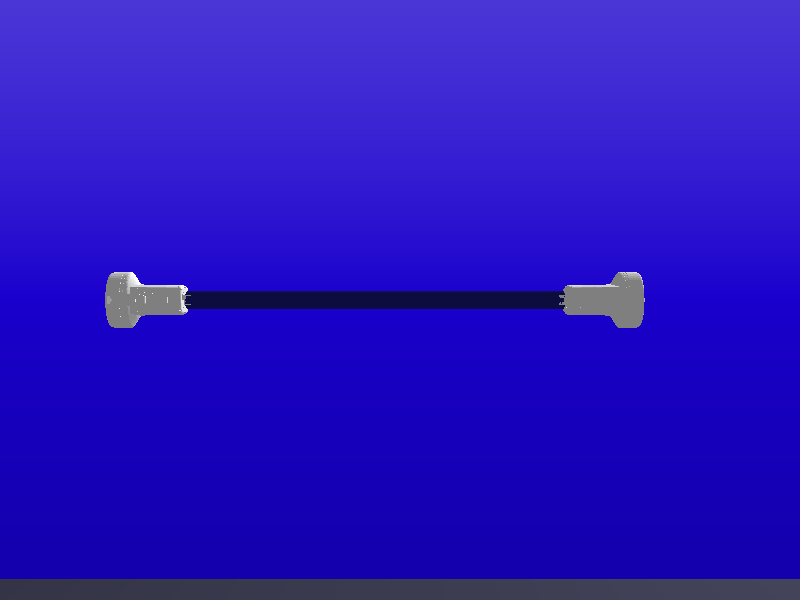

In [2]:
from panda3d.core import loadPrcFileData

loadPrcFileData("", "window-type offscreen")
loadPrcFileData("", "win-size 640 480")

import numpy as np
from PIL import Image
from IPython.display import display

import jax

jax.config.update("jax_enable_x64", True)

from ajx.example_graphics.environment_scene import EnvironmentScene
from ajx.example_graphics.application import Application
from ajx.constraints import ConstraintType
from ajx.example_environments.dlo import DLO, DLOSettings, CableParameters
from ajx.simulation import SimulationSettings, Solver
import jax.numpy as jnp
import ajx.math as math
from ajx import Transform


timestep = 1/60
grippermc_to_marker = jnp.array([0.0478024, 0, 0])
environment = DLO(
    sim_settings=SimulationSettings(timestep, True, Solver.DENSE_LINEAR),
    env_settings=DLOSettings.create(
        n_segments=50,
        length=0.6,
        radius=0.015,
        constraint_type=ConstraintType.SE3.value,
        density=1000,
        pose_estimate_linear_offsets=[0.10, 0.20, 0.30, 0.40, 0.50],
        gripper1_offset=Transform(grippermc_to_marker, math.Rotations.unitary),
        gripper2_offset=Transform(-grippermc_to_marker, math.Rotations.unitary),
        loose_end=False,
    ),
)
nu = 0.333
E = 1e7
cable_param = CableParameters(
    youngs_modulus=E,
    shear_modulus=E / (2 * (1 + nu)),
    damping=environment.default_param.sparse_param.cable_param.damping,
)

env_param = environment.default_param.tree_replace(
    src={"sparse_param.cable_param": cable_param}
)

initial_state = environment.get_neutral_state(env_param)

scene = EnvironmentScene(environment, env_param, initial_state, show_text=False, show_fps=False, debug_render=False)
if "app" in locals():
    app.destroy()
    del app
app = Application(scene, 60, "default", headless=True)
scene.update_geometry()
img = app.get_headless_frame()
display(img)

## Simulate and animate the DLO

In [3]:

import imageio
from IPython.display import Video
writer = imageio.get_writer("animation.mp4", fps=60)

# Create an interesting control signal
horizon = 400
u = np.zeros([horizon, 12])
# u[:400, 5] = 4.0
# u[:400, 11] = -4.0
# u[:50, 5] = 0
# u[:50, 11] = 0
# u[250:, 5] = 0
# u[250:, 11] = 0
# u[200:600, 0] = np.cos(np.linspace(0, 20, 400)) 
# u[200:600, 6] = -np.cos(np.linspace(0, 20, 400))
# u[400:600, 2] = 1.0
# u[400:600, 8] = -1.0

# u[400:600, 5] = -1.0
# u[400:600, 11] = 1.0
# u[600:] = 0.0
u[:100,0] = -0.2
u[150:200,3] = -1.0

u = jnp.array(u)
store_poses_at = [150, 300]
results = []

# Allocate an array to store the observations over time
env_step = jax.jit(environment.step)
state = initial_state
frames = []
# Simulation loop
for i in range(horizon):
    # Step the environment and store the observation
    state, observations = env_step(state, u[i], env_param)
    scene.state = state
    scene.update_geometry()
    app.graphicsEngine.renderFrame()
    frame = app.get_headless_frame()
    writer.append_data(np.array(frame))
    if i in store_poses_at:
        results.append(observations)
writer.close()

Video("animation.mp4")

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 600) to (800, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
/usr/lib/python3.14/subprocess.py:1919: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


## Sim2sim parameter estimation
Suppose that we want to find the parameters that support the final pose in the trajectory that was just generated

In [7]:
from ajx.tree_util import tangent_jacfwd
from ajx.definitions import State, GeneralizedVelocity
from ajx.example_environments.dlo import DLOState
target_pose = state.conf
lock_targets = state.lock_targets
start_err = jnp.linalg.norm(state.gvel.data)
env = environment
n_bodies = env.env_settings.n_segments

# # The critera is that we should get no velocity
def forward_dynamics_residual(param):
    gvel = GeneralizedVelocity(jnp.zeros([n_bodies+2, 6]))
    state = DLOState(target_pose, gvel, lock_targets)
    next_state = env.step_state(state, jnp.zeros([12]), param)
    return next_state.gvel.data.flatten()


# The critera is that we should get no force
def inverse_dynamics_residual(param):
    gvel = GeneralizedVelocity(jnp.zeros([n_bodies+2, 6]))
    state = DLOState(target_pose, gvel, lock_targets)
    force = env.sim.inverse_dynamics(state, gvel, jnp.zeros([12]), param)
    return force.flatten()

residual = inverse_dynamics_residual
jac_r = tangent_jacfwd(residual)

def gauss_newton(x0, n_iter, damping):
    x = x0
    for i in range(n_iter):
        rx = residual(x)  # shape (m,)
        J = jac_r(x)  # shape (m, n)

        # Gauss-Newton step: solve (J^T J) delta = -J^T r
        JTJ = J.T @ J + jnp.eye(J.shape[1]) * damping
        JTr = J.T @ rx
        delta = -jnp.linalg.solve(JTJ, JTr)

        x = x.retract(delta)
        print(f"Iter: {i}\t |rx|: {jnp.linalg.norm(rx)}")
    return x, J



# Pretend that stiffness is unknown
env_param = env.default_param.tree_replace(src={
    "sparse_param.cable_param.youngs_modulus":  1e4,
    "sparse_param.cable_param.shear_modulus":  1e4,
})

# Set stiffness as tunable
env_param = env_param.replace(
    tangent_restrictions=(
        "sparse_param.cable_param.youngs_modulus",
        "sparse_param.cable_param.shear_modulus",
    )
)

# Optimize
solution, Js = gauss_newton(env_param, n_iter=50, damping=0.0)


Iter: 0	 |rx|: 0.9549238370039347
Iter: 1	 |rx|: 0.03192526869249874
Iter: 2	 |rx|: 0.031925268692498794
Iter: 3	 |rx|: 0.031925268692498794
Iter: 4	 |rx|: 0.031925268692498794
Iter: 5	 |rx|: 0.031925268692498794
Iter: 6	 |rx|: 0.031925268692498794
Iter: 7	 |rx|: 0.031925268692498794
Iter: 8	 |rx|: 0.031925268692498794
Iter: 9	 |rx|: 0.031925268692498794
Iter: 10	 |rx|: 0.031925268692498794
Iter: 11	 |rx|: 0.031925268692498794
Iter: 12	 |rx|: 0.031925268692498794
Iter: 13	 |rx|: 0.031925268692498794
Iter: 14	 |rx|: 0.031925268692498794
Iter: 15	 |rx|: 0.031925268692498794
Iter: 16	 |rx|: 0.031925268692498794
Iter: 17	 |rx|: 0.031925268692498794
Iter: 18	 |rx|: 0.031925268692498794
Iter: 19	 |rx|: 0.031925268692498794
Iter: 20	 |rx|: 0.031925268692498794
Iter: 21	 |rx|: 0.031925268692498794
Iter: 22	 |rx|: 0.031925268692498794
Iter: 23	 |rx|: 0.031925268692498794
Iter: 24	 |rx|: 0.031925268692498794
Iter: 25	 |rx|: 0.031925268692498794
Iter: 26	 |rx|: 0.031925268692498794
Iter: 27	 |rx|

In [8]:
# Print results
youngs_modulus = solution.sparse_param.cable_param.youngs_modulus
shear_modulus = solution.sparse_param.cable_param.shear_modulus
poissons_ratio = youngs_modulus / (2 * shear_modulus) - 1
print(
    f"Stiffness (youngs, shear, poissons): \t{youngs_modulus}, {shear_modulus}, {poissons_ratio}"
)

# Estimate uncertainty
U, S, V = jnp.linalg.svd(Js)

JTJ_inv = V @ jnp.diag((1/(S+1e-16))**2) @ V.T
residual_sample_variance = jnp.linalg.norm(residual(solution))**2 / (residual(solution).shape[0] - env_param.tangent_size())
cov = JTJ_inv * residual_sample_variance
parameter_std = jnp.sqrt(jnp.diag(cov))
print(f"Standard deviation estimate: \t\t{parameter_std[:3]}")

Stiffness (youngs, shear, poissons): 	10007439.20826115, 3705652.933409241, 0.3502936443449114
Standard deviation estimate: 		[ 18998.50255691 322121.53162024]


In [6]:

import pickle
with open('observations.pickle', 'wb') as handle:
    pickle.dump(observations, handle, protocol=pickle.HIGHEST_PROTOCOL)